# Load Data

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib import colormaps
from matplotlib.patches import Patch



In [194]:
# Load Datasets
data_java = 'Datasets/measurements_Java.csv'
data_javascript = 'Datasets/measurements_Javascript.csv'
data_PHP = 'Datasets/measurements_PHP.csv'
data_ruby = 'Datasets/measurements_Ruby.csv'
data_python = 'Datasets/measurements_Python.csv'
data_lua = 'Datasets/measurements_Lua.csv'
data_erlang = 'Datasets/measurements_Erlang.csv'

data_csharp = 'Datasets/measurements_CSharp.csv'
data_dart = 'Datasets/measurements_Dart.csv'

df_data_csharp = pd.read_csv(data_csharp, header = 0, delimiter=",", decimal=".", names=['Language','Program','Powercap','Package','Core','GPU','DRAM','Time','Temperature','Memory'])
df_data_dart = pd.read_csv(data_dart, header = 0, delimiter=",", decimal=".", names=['Language','Program','Powercap','Package','Core','GPU','DRAM','Time','Temperature','Memory'])

df_data_java = pd.read_csv(data_java, header = 0, delimiter=",", decimal=".", names=['Language','Program','Powercap','Package','Core','GPU','DRAM','Time','Temperature','Memory'])
df_data_javascript = pd.read_csv(data_javascript, header = 0, delimiter=",", decimal=".", names=['Language','Program','Powercap','Package','Core','GPU','DRAM','Time','Temperature','Memory'])
df_data_PHP = pd.read_csv(data_PHP, header = 0, delimiter=",", decimal=".", names=['Language','Program','Powercap','Package','Core','GPU','DRAM','Time','Temperature','Memory'])
df_data_ruby = pd.read_csv(data_ruby, header = 0, delimiter=",", decimal=".", names=['Language','Program','Powercap','Package','Core','GPU','DRAM','Time','Temperature','Memory'])
df_data_python = pd.read_csv(data_python, header = 0, delimiter=",", decimal=".", names=['Language','Program','Powercap','Package','Core','GPU','DRAM','Time','Temperature','Memory'])
df_data_lua = pd.read_csv(data_lua, header = 0, delimiter=",", decimal=".", names=['Language','Program','Powercap','Package','Core','GPU','DRAM','Time','Temperature','Memory'])
df_data_erlang = pd.read_csv(data_erlang, header = 0, delimiter=",", decimal=".", names=['Language','Program','Powercap','Package','Core','GPU','DRAM','Time','Temperature','Memory'])

df_data_java = df_data_java[~df_data_java["Language"].str.startswith("JavaXComp", na=False)]

dfs = {
    "df_data_java": df_data_java,
    "df_data_javascript": df_data_javascript,
    "df_data_PHP": df_data_PHP,
    "df_data_ruby": df_data_ruby,
    "df_data_python3": df_data_python,
    "df_data_lua": df_data_lua,
    "df_data_erlang": df_data_erlang
}

dfsL = [df_data_java, df_data_javascript, df_data_PHP, df_data_ruby, df_data_python, df_data_lua, df_data_erlang]


In [ ]:
def clean_dataframe(df, df_name, group_cols, value_col,
                    drop_col=None,
                    startswith_col=None,
                    startswith_value=None):
    
    # Drop column if provided
    if drop_col is not None:
        df = df.drop(columns=drop_col)
    
    # Remove rows that start with a given string
    if startswith_col is not None and startswith_value is not None:
        df = df[~df[startswith_col].str.startswith(startswith_value, na=False)]

    def trim_group(group):
        return group.iloc[1:-1]

    df = pd.concat([
        trim_group(group)
        for name, group in df.sort_values(value_col).groupby(group_cols)
    ]).reset_index(drop=True)

    # Averages by Program
    df = (df.groupby(["Language","Program"], as_index=False).mean(numeric_only=True))
    df["Program"] = df["Program"].str.replace(r"_\d+$", "", regex=True)
    df["Time"] = df["Time"] / 1000
    df = df.sort_values(by=["Program", "Language"], na_position="first")
    
    file_path = f"{df_name}.csv"
    df.to_csv(file_path, index=False)

    return df

filtered_dfs = [
    clean_dataframe(
        df,
        df_name,
        group_cols=["Language", "Program"],
        value_col="Package",
        drop_col="Powercap",
        startswith_col="Program",
        startswith_value=" idle_"
    )
    for df_name, df in dfs.items()
]

# Análise de Dados

## FINAL RESULTS

### Java

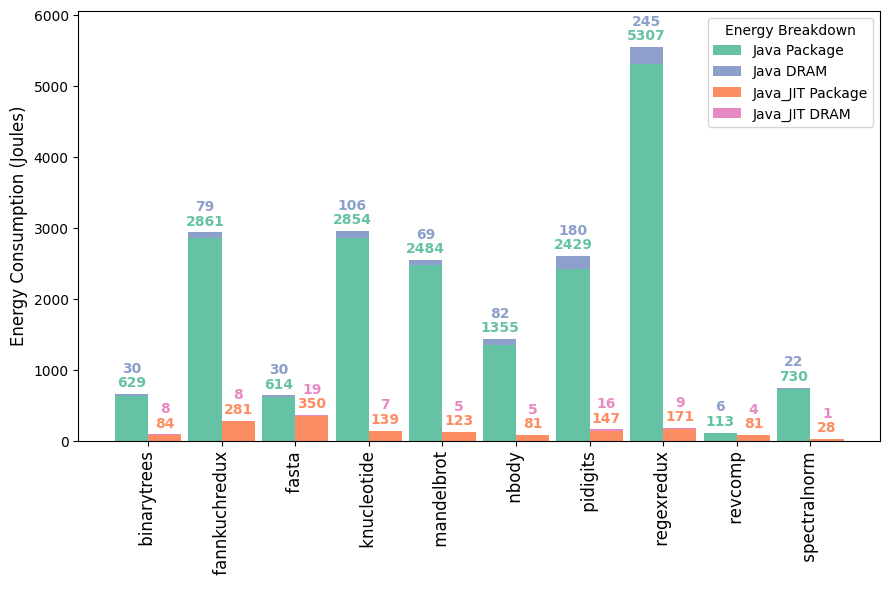

In [267]:
java_df = filtered_dfs[0].copy().round(0)
java_df["Program"] = java_df["Program"].str.split('.').str[0]

programs = java_df["Program"].unique()
languages = java_df["Language"].unique()

pivot_pkg = java_df.pivot(index="Program", columns="Language", values="Package")
pivot_dram = java_df.pivot(index="Program", columns="Language", values="DRAM")

x = np.arange(len(programs))
width = 0.45

# Colorblind-friendly palette
pkg_colors = ["#66c2a5", "#fc8d62"]
dram_colors = ["#8da0cb", "#e78ac3"]

fig, ax = plt.subplots(figsize=(9,6))

for i, lang in enumerate(languages):

    bar_offset = (i - 0.5) * width

    pkg = pivot_pkg[lang].values
    dram = pivot_dram[lang].values

    # Package bars
    pkg_bars = ax.bar(
        x + bar_offset,
        pkg,
        width,
        color=pkg_colors[i],
        label=f"{lang} Package"
    )

    # DRAM stacked bars
    dram_bars = ax.bar(
        x + bar_offset,
        dram,
        width,
        bottom=pkg,
        color=dram_colors[i],
        label=f"{lang} DRAM"
    )
    
    ymin, ymax = ax.get_ylim()
    offset = 0.01 * (ymax - ymin)

    for j in range(len(x)):

        total_height = pkg[j] + dram[j]

        # Package value (lower text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset,
            f"{pkg[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=pkg_colors[i],
            fontweight="bold"
        )

        # DRAM value (upper text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset*4.5,
            f"{dram[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=dram_colors[i],
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(programs, rotation=90, fontsize=12)

ax.set_ylabel("Energy Consumption (Joules)", fontsize=12)

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.04)

legend_elements = [
    Patch(facecolor=pkg_colors[0], label=f"{languages[0]} Package"),
    Patch(facecolor=dram_colors[0], label=f"{languages[0]} DRAM"),
    Patch(facecolor=pkg_colors[1], label=f"{languages[1]} Package"),
    Patch(facecolor=dram_colors[1], label=f"{languages[1]} DRAM"),
]

ax.legend(handles=legend_elements, title="Energy Breakdown")

plt.tight_layout()
plt.savefig("Images/java_energy.pdf", bbox_inches='tight', format='pdf')
plt.show()



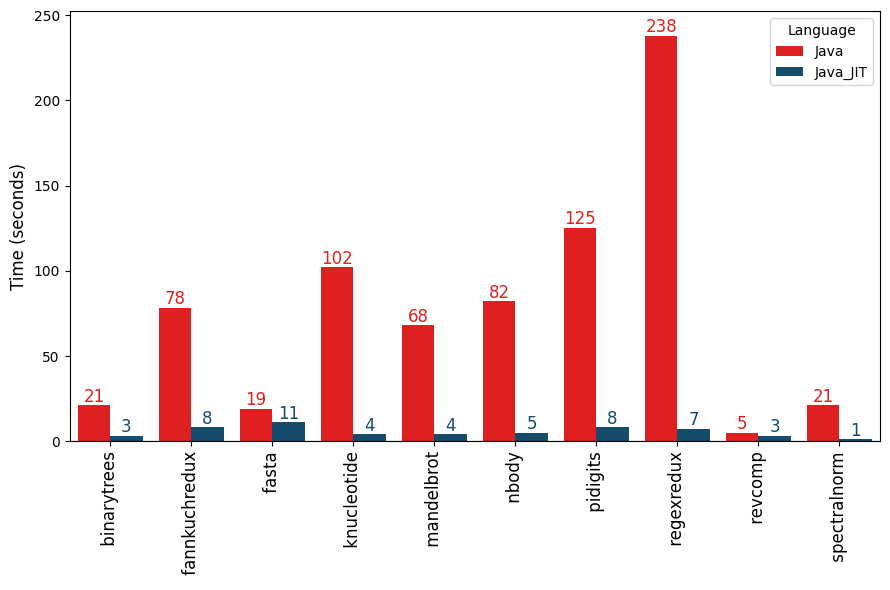

In [268]:
plt.figure(figsize=(9,6))
colors = ["#FF0000", "#074F79"]

ax = sns.barplot(
    data=java_df,
    x="Program",
    y="Time",
    hue="Language",
    palette=colors
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Time (seconds)", fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.xlabel("")

for bar in ax.patches:
    height = bar.get_height()
    
    if height == 0: # skip fake zero bars
        continue

    x = bar.get_x() + bar.get_width() / 2

    ax.text(
        x,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        color=bar.get_facecolor(),
        fontsize=12
    )

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.01)

plt.tight_layout()
plt.savefig("Images/java_time.pdf", bbox_inches='tight', format='pdf')
plt.show()

### Javascript

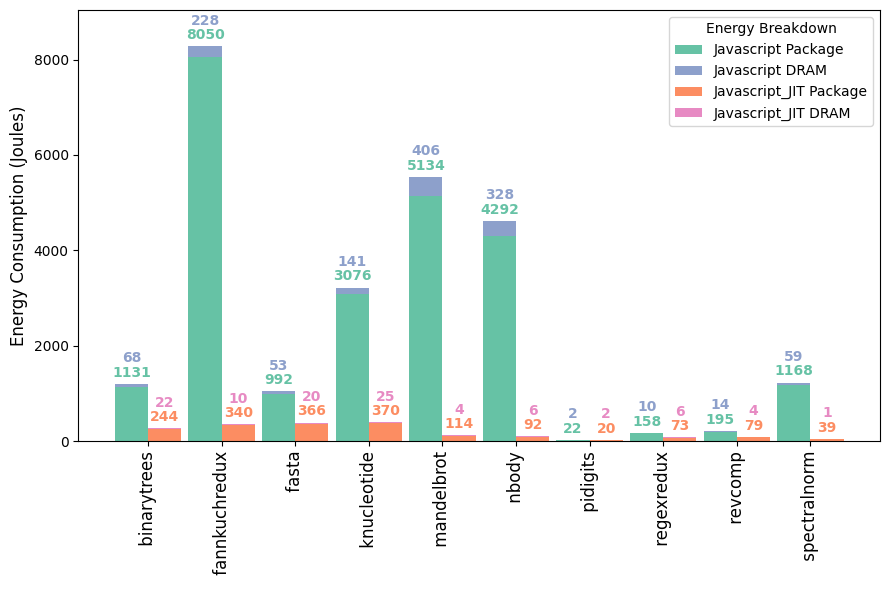

In [269]:
node_df = filtered_dfs[1].copy().round(0)
node_df["Program"] = node_df["Program"].str.split('.').str[0]

programs = node_df["Program"].unique()
languages = node_df["Language"].unique()

pivot_pkg = node_df.pivot(index="Program", columns="Language", values="Package")
pivot_dram = node_df.pivot(index="Program", columns="Language", values="DRAM")

x = np.arange(len(programs))
width = 0.45

# Colorblind-friendly palette
pkg_colors = ["#66c2a5", "#fc8d62"]
dram_colors = ["#8da0cb", "#e78ac3"]

fig, ax = plt.subplots(figsize=(9,6))

for i, lang in enumerate(languages):

    bar_offset = (i - 0.5) * width

    pkg = pivot_pkg[lang].values
    dram = pivot_dram[lang].values

    # Package bars
    pkg_bars = ax.bar(
        x + bar_offset,
        pkg,
        width,
        color=pkg_colors[i],
        label=f"{lang} Package"
    )

    # DRAM stacked bars
    dram_bars = ax.bar(
        x + bar_offset,
        dram,
        width,
        bottom=pkg,
        color=dram_colors[i],
        label=f"{lang} DRAM"
    )

    ymin, ymax = ax.get_ylim()
    offset = 0.01 * (ymax - ymin)

    for j in range(len(x)):

        total_height = pkg[j] + dram[j]

        # Package value (lower text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset,
            f"{pkg[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=pkg_colors[i],
            fontweight="bold"
        )

        # DRAM value (upper text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset*4.5,
            f"{dram[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=dram_colors[i],
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(programs, rotation=90, fontsize=12)

ax.set_ylabel("Energy Consumption (Joules)", fontsize=12)

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.04)

legend_elements = [
    Patch(facecolor=pkg_colors[0], label=f"{languages[0]} Package"),
    Patch(facecolor=dram_colors[0], label=f"{languages[0]} DRAM"),
    Patch(facecolor=pkg_colors[1], label=f"{languages[1]} Package"),
    Patch(facecolor=dram_colors[1], label=f"{languages[1]} DRAM"),
]

ax.legend(handles=legend_elements, title="Energy Breakdown")

plt.tight_layout()
plt.savefig("Images/javascript_energy.pdf", bbox_inches='tight', format='pdf')
plt.show()

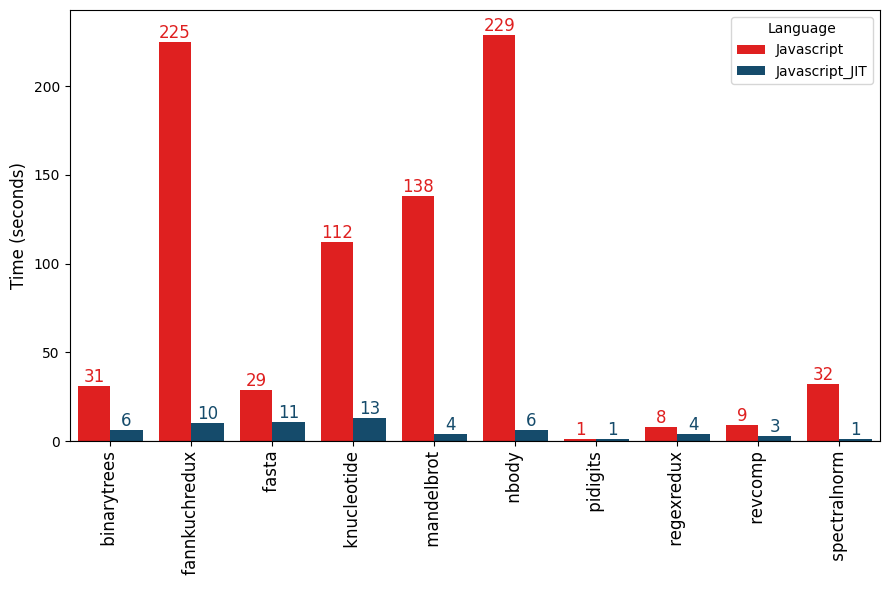

In [270]:
plt.figure(figsize=(9,6))
colors = ["#FF0000", "#074F79"]

ax = sns.barplot(
    data=node_df,
    x="Program",
    y="Time",
    hue="Language",
    palette=colors
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Time (seconds)", fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.xlabel("")

for bar in ax.patches:
    height = bar.get_height()
    
    if height == 0: # skip fake zero bars
        continue

    x = bar.get_x() + bar.get_width() / 2

    ax.text(
        x,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        color=bar.get_facecolor(),
        fontsize=12
    )

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.01)

plt.tight_layout()
plt.savefig("Images/javascript_time.pdf", bbox_inches='tight', format='pdf')
plt.show()


### PHP

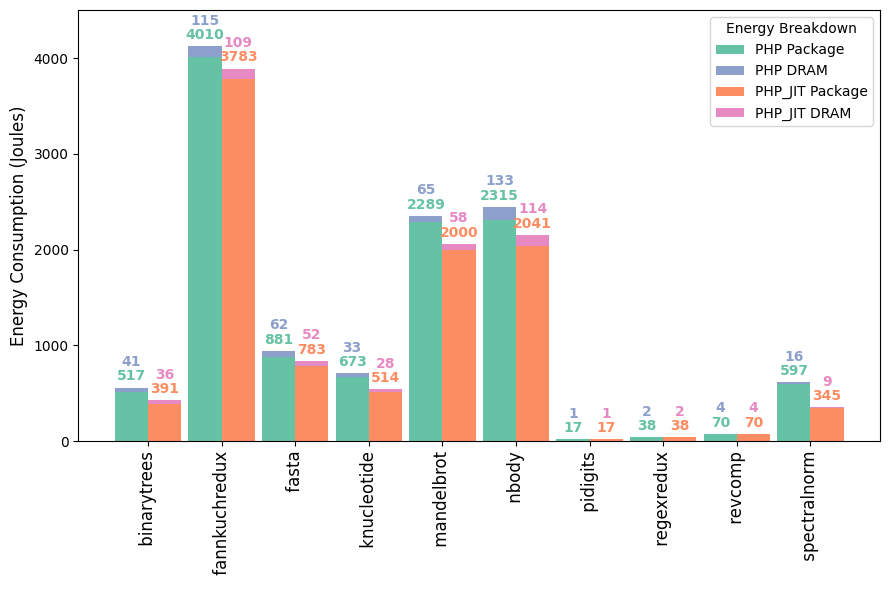

In [271]:
php_df = filtered_dfs[2].copy().round(0)
php_df["Program"] = php_df["Program"].str.split('.').str[0]

programs = php_df["Program"].unique()
languages = php_df["Language"].unique()

pivot_pkg = php_df.pivot(index="Program", columns="Language", values="Package")
pivot_dram = php_df.pivot(index="Program", columns="Language", values="DRAM")

x = np.arange(len(programs))
width = 0.45

# Colorblind-friendly palette
pkg_colors = ["#66c2a5", "#fc8d62"]
dram_colors = ["#8da0cb", "#e78ac3"]

fig, ax = plt.subplots(figsize=(9,6))

for i, lang in enumerate(languages):

    bar_offset = (i - 0.5) * width

    pkg = pivot_pkg[lang].values
    dram = pivot_dram[lang].values

    # Package bars
    pkg_bars = ax.bar(
        x + bar_offset,
        pkg,
        width,
        color=pkg_colors[i],
        label=f"{lang} Package"
    )

    # DRAM stacked bars
    dram_bars = ax.bar(
        x + bar_offset,
        dram,
        width,
        bottom=pkg,
        color=dram_colors[i],
        label=f"{lang} DRAM"
    )

    ymin, ymax = ax.get_ylim()
    offset = 0.01 * (ymax - ymin)

    for j in range(len(x)):

        total_height = pkg[j] + dram[j]

        # Package value (lower text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset,
            f"{pkg[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=pkg_colors[i],
            fontweight="bold"
        )

        # DRAM value (upper text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset*4.5,
            f"{dram[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=dram_colors[i],
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(programs, rotation=90, fontsize=12)

ax.set_ylabel("Energy Consumption (Joules)", fontsize=12)

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.04)

legend_elements = [
    Patch(facecolor=pkg_colors[0], label=f"{languages[0]} Package"),
    Patch(facecolor=dram_colors[0], label=f"{languages[0]} DRAM"),
    Patch(facecolor=pkg_colors[1], label=f"{languages[1]} Package"),
    Patch(facecolor=dram_colors[1], label=f"{languages[1]} DRAM"),
]

ax.legend(handles=legend_elements, title="Energy Breakdown")

plt.tight_layout()
plt.savefig("Images/php_energy.pdf", bbox_inches='tight', format='pdf')
plt.show()

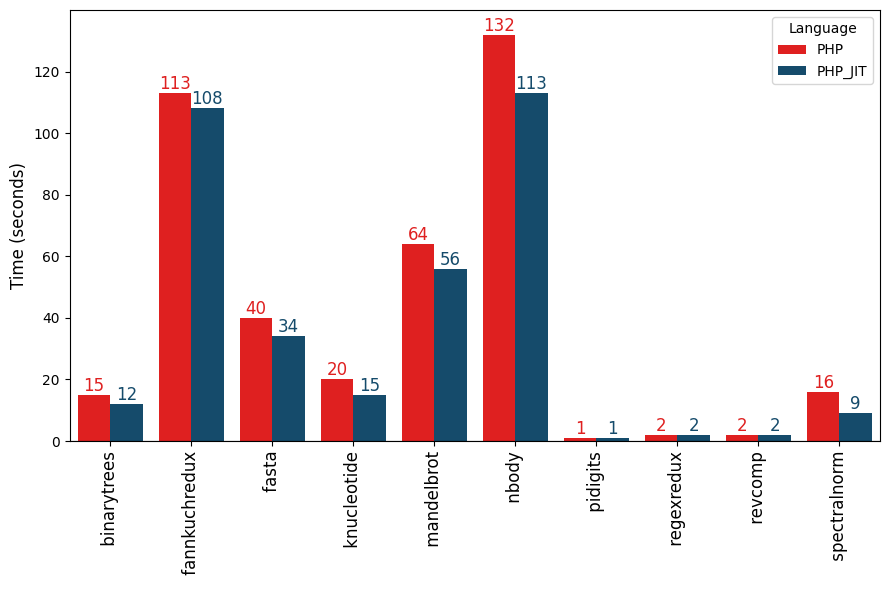

In [273]:
plt.figure(figsize=(9,6))
colors = ["#FF0000", "#074F79"]

ax = sns.barplot(
    data=php_df,
    x="Program",
    y="Time",
    hue="Language",
    palette=colors
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Time (seconds)", fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.xlabel("")

for bar in ax.patches:
    height = bar.get_height()
    
    if height == 0: # skip fake zero bars
        continue

    x = bar.get_x() + bar.get_width() / 2

    ax.text(
        x,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        color=bar.get_facecolor(),
        fontsize=12
    )

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.01)

plt.tight_layout()
plt.savefig("Images/php_time.pdf", bbox_inches='tight', format='pdf')
plt.show()


### Ruby

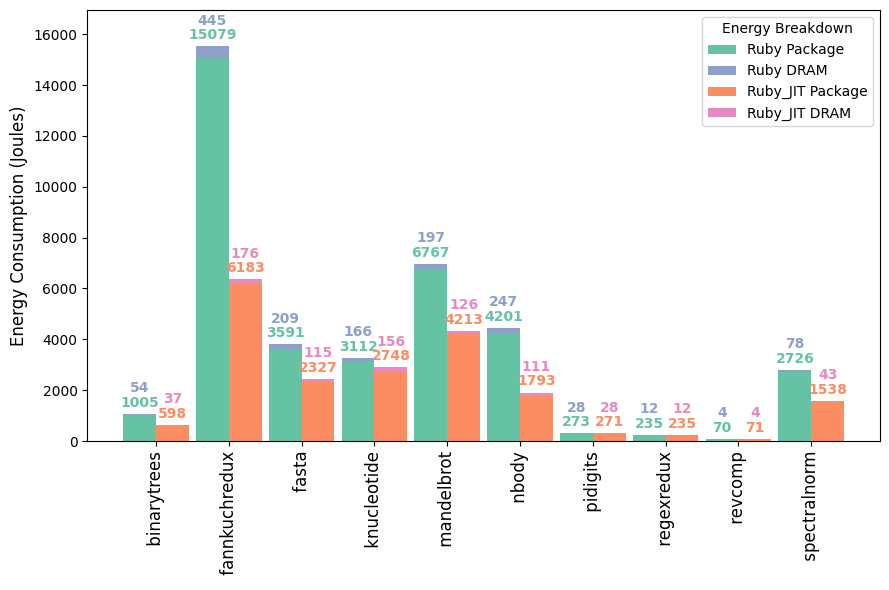

In [278]:
ruby_df = filtered_dfs[3].copy().round(0)
ruby_df["Program"] = ruby_df["Program"].str.split('.').str[0]

programs = ruby_df["Program"].unique()
languages = ruby_df["Language"].unique()

pivot_pkg = ruby_df.pivot(index="Program", columns="Language", values="Package")
pivot_dram = ruby_df.pivot(index="Program", columns="Language", values="DRAM")

x = np.arange(len(programs))
width = 0.45

# Colorblind-friendly palette
pkg_colors = ["#66c2a5", "#fc8d62"]
dram_colors = ["#8da0cb", "#e78ac3"]

fig, ax = plt.subplots(figsize=(9,6))

for i, lang in enumerate(languages):

    bar_offset = (i - 0.5) * width

    pkg = pivot_pkg[lang].values
    dram = pivot_dram[lang].values

    # Package bars
    pkg_bars = ax.bar(
        x + bar_offset,
        pkg,
        width,
        color=pkg_colors[i],
        label=f"{lang} Package"
    )

    # DRAM stacked bars
    dram_bars = ax.bar(
        x + bar_offset,
        dram,
        width,
        bottom=pkg,
        color=dram_colors[i],
        label=f"{lang} DRAM"
    )

    ymin, ymax = ax.get_ylim()
    offset = 0.01 * (ymax - ymin)

    for j in range(len(x)):

        total_height = pkg[j] + dram[j]

        # Package value (lower text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset,
            f"{pkg[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=pkg_colors[i],
            fontweight="bold"
        )

        # DRAM value (upper text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset*4.5,
            f"{dram[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=dram_colors[i],
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(programs, rotation=90, fontsize=12)

ax.set_ylabel("Energy Consumption (Joules)", fontsize=12)

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.04)

legend_elements = [
    Patch(facecolor=pkg_colors[0], label=f"{languages[0]} Package"),
    Patch(facecolor=dram_colors[0], label=f"{languages[0]} DRAM"),
    Patch(facecolor=pkg_colors[1], label=f"{languages[1]} Package"),
    Patch(facecolor=dram_colors[1], label=f"{languages[1]} DRAM"),
]

ax.legend(handles=legend_elements, title="Energy Breakdown")

plt.tight_layout()
plt.savefig("Images/ruby_energy.pdf", bbox_inches='tight', format='pdf')
plt.show()

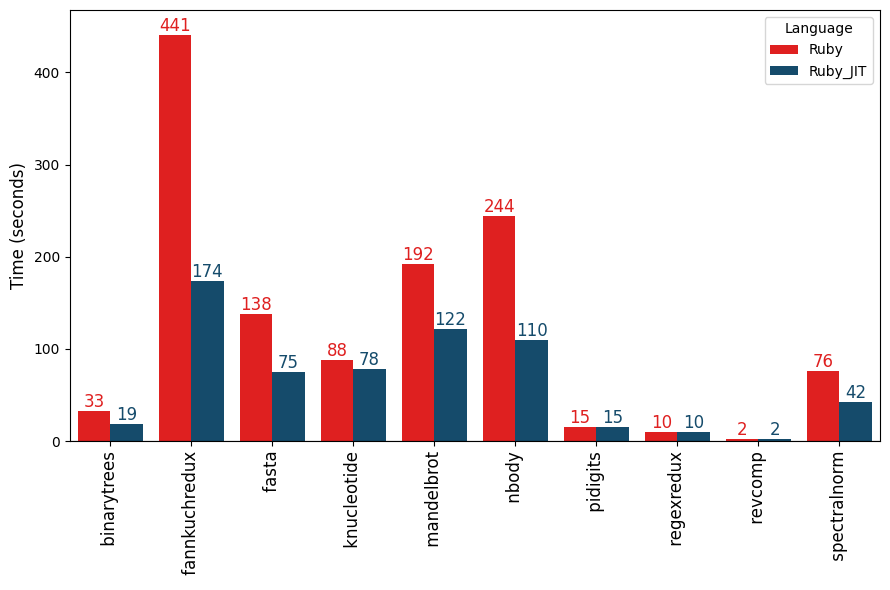

In [279]:
plt.figure(figsize=(9,6))
colors = ["#FF0000", "#074F79"]

ax = sns.barplot(
    data=ruby_df,
    x="Program",
    y="Time",
    hue="Language",
    palette=colors
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Time (seconds)", fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.xlabel("")

for bar in ax.patches:
    height = bar.get_height()
    
    if height == 0: # skip fake zero bars
        continue

    x = bar.get_x() + bar.get_width() / 2

    ax.text(
        x,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        color=bar.get_facecolor(),
        fontsize=12
    )

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.01)

plt.tight_layout()
plt.savefig("Images/ruby_time.pdf", bbox_inches='tight', format='pdf')
plt.show()


### Python

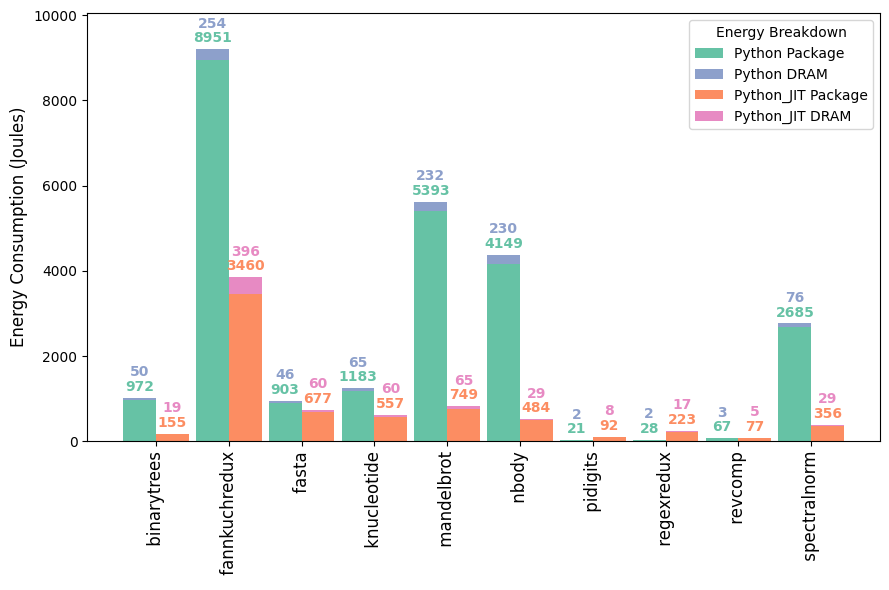

In [280]:
python_df = filtered_dfs[4].copy().round(0)
python_df["Program"] = python_df["Program"].str.split('.').str[0]

programs = python_df["Program"].unique()
languages = python_df["Language"].unique()

pivot_pkg = python_df.pivot(index="Program", columns="Language", values="Package")
pivot_dram = python_df.pivot(index="Program", columns="Language", values="DRAM")

x = np.arange(len(programs))
width = 0.45

# Colorblind-friendly palette
pkg_colors = ["#66c2a5", "#fc8d62"]
dram_colors = ["#8da0cb", "#e78ac3"]

fig, ax = plt.subplots(figsize=(9,6))

for i, lang in enumerate(languages):

    bar_offset = (i - 0.5) * width

    pkg = pivot_pkg[lang].values
    dram = pivot_dram[lang].values

    # Package bars
    pkg_bars = ax.bar(
        x + bar_offset,
        pkg,
        width,
        color=pkg_colors[i],
        label=f"{lang} Package"
    )

    # DRAM stacked bars
    dram_bars = ax.bar(
        x + bar_offset,
        dram,
        width,
        bottom=pkg,
        color=dram_colors[i],
        label=f"{lang} DRAM"
    )

    ymin, ymax = ax.get_ylim()
    offset = 0.01 * (ymax - ymin)

    for j in range(len(x)):

        total_height = pkg[j] + dram[j]

        # Package value (lower text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset,
            f"{pkg[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=pkg_colors[i],
            fontweight="bold"
        )

        # DRAM value (upper text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset*4.5,
            f"{dram[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=dram_colors[i],
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(programs, rotation=90, fontsize=12)

ax.set_ylabel("Energy Consumption (Joules)", fontsize=12)

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.04)

legend_elements = [
    Patch(facecolor=pkg_colors[0], label=f"{languages[0]} Package"),
    Patch(facecolor=dram_colors[0], label=f"{languages[0]} DRAM"),
    Patch(facecolor=pkg_colors[1], label=f"{languages[1]} Package"),
    Patch(facecolor=dram_colors[1], label=f"{languages[1]} DRAM"),
]

ax.legend(handles=legend_elements, title="Energy Breakdown")

plt.tight_layout()
plt.savefig("Images/python_energy.pdf", bbox_inches='tight', format='pdf')
plt.show()

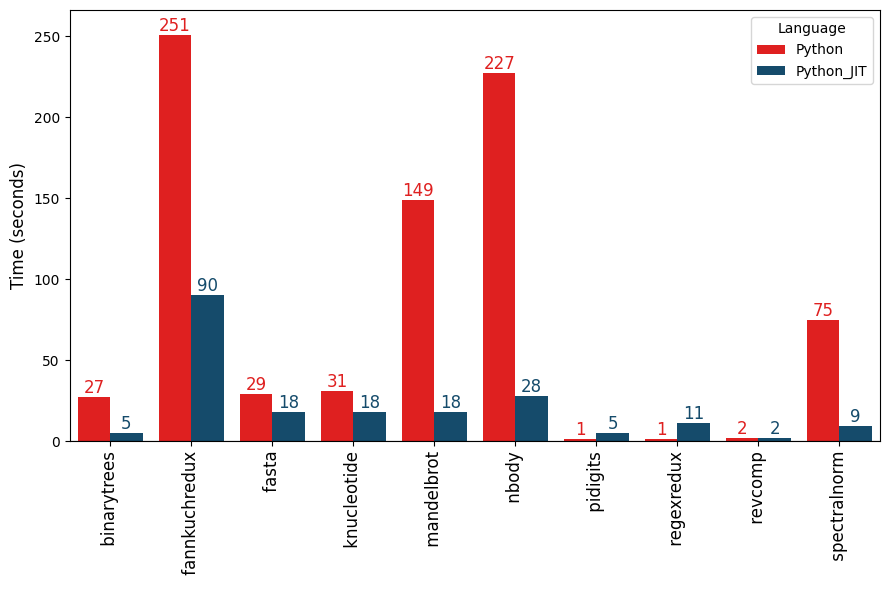

In [281]:
plt.figure(figsize=(9,6))
colors = ["#FF0000", "#074F79"]

ax = sns.barplot(
    data=python_df,
    x="Program",
    y="Time",
    hue="Language",
    palette=colors
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Time (seconds)", fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.xlabel("")

for bar in ax.patches:
    height = bar.get_height()
    
    if height == 0: # skip fake zero bars
        continue

    x = bar.get_x() + bar.get_width() / 2

    ax.text(
        x,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        color=bar.get_facecolor(),
        fontsize=12
    )

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.01)

plt.tight_layout()
plt.savefig("Images/python_time.pdf", bbox_inches='tight', format='pdf')
plt.show()


### Lua

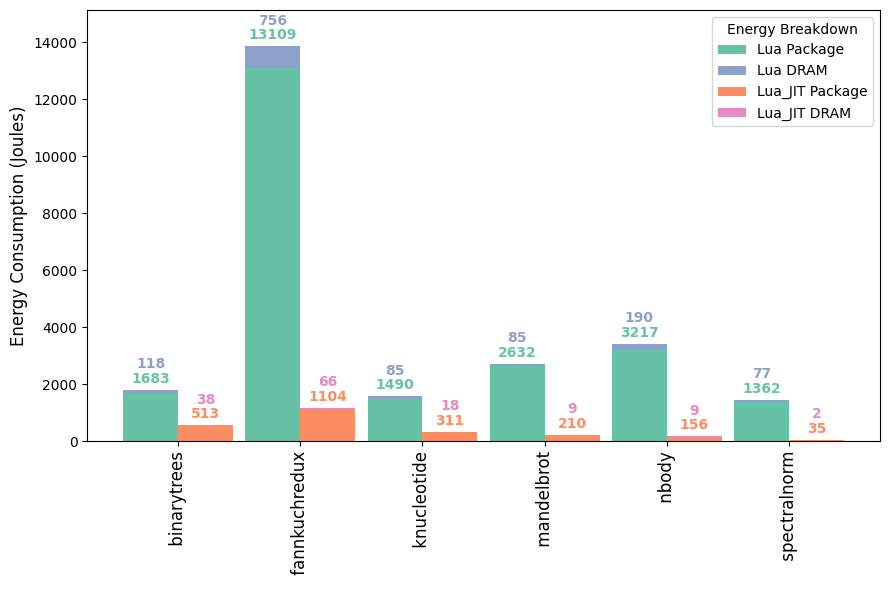

In [282]:
lua_df = filtered_dfs[5].copy().round(0)
lua_df["Program"] = lua_df["Program"].str.split('.').str[0]

programs = lua_df["Program"].unique()
languages = lua_df["Language"].unique()

pivot_pkg = lua_df.pivot(index="Program", columns="Language", values="Package")
pivot_dram = lua_df.pivot(index="Program", columns="Language", values="DRAM")

x = np.arange(len(programs))
width = 0.45

# Colorblind-friendly palette
pkg_colors = ["#66c2a5", "#fc8d62"]
dram_colors = ["#8da0cb", "#e78ac3"]

fig, ax = plt.subplots(figsize=(9,6))

for i, lang in enumerate(languages):

    bar_offset = (i - 0.5) * width

    pkg = pivot_pkg[lang].values
    dram = pivot_dram[lang].values

    # Package bars
    pkg_bars = ax.bar(
        x + bar_offset,
        pkg,
        width,
        color=pkg_colors[i],
        label=f"{lang} Package"
    )

    # DRAM stacked bars
    dram_bars = ax.bar(
        x + bar_offset,
        dram,
        width,
        bottom=pkg,
        color=dram_colors[i],
        label=f"{lang} DRAM"
    )

    ymin, ymax = ax.get_ylim()
    offset = 0.01 * (ymax - ymin)

    for j in range(len(x)):

        total_height = pkg[j] + dram[j]

        # Package value (lower text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset,
            f"{pkg[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=pkg_colors[i],
            fontweight="bold"
        )

        # DRAM value (upper text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset*4.5,
            f"{dram[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=dram_colors[i],
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(programs, rotation=90, fontsize=12)

ax.set_ylabel("Energy Consumption (Joules)", fontsize=12)

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.04)

legend_elements = [
    Patch(facecolor=pkg_colors[0], label=f"{languages[0]} Package"),
    Patch(facecolor=dram_colors[0], label=f"{languages[0]} DRAM"),
    Patch(facecolor=pkg_colors[1], label=f"{languages[1]} Package"),
    Patch(facecolor=dram_colors[1], label=f"{languages[1]} DRAM"),
]

ax.legend(handles=legend_elements, title="Energy Breakdown")

plt.tight_layout()
plt.savefig("Images/lua_energy.pdf", bbox_inches='tight', format='pdf')
plt.show()

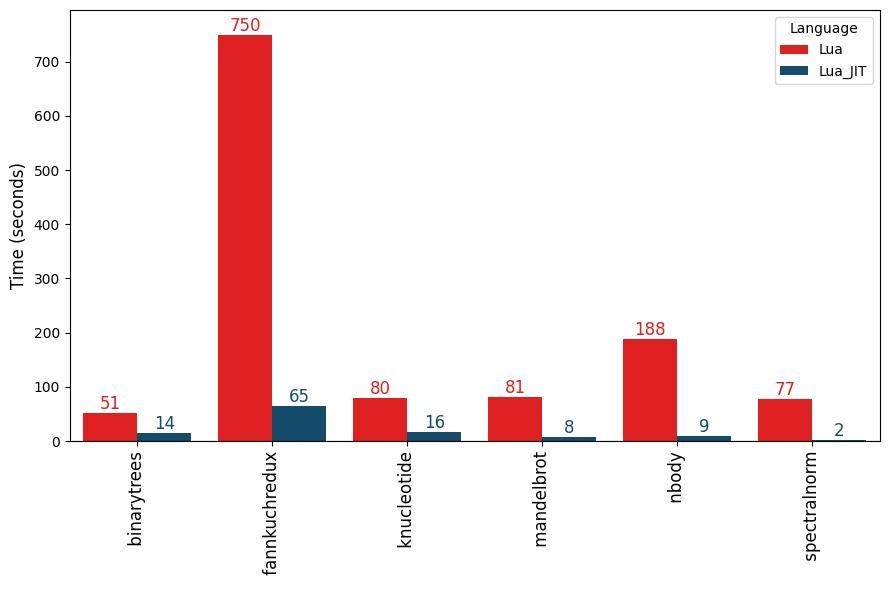

In [283]:
plt.figure(figsize=(9,6))
colors = ["#FF0000", "#074F79"]

ax = sns.barplot(
    data=lua_df,
    x="Program",
    y="Time",
    hue="Language",
    palette=colors
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Time (seconds)", fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.xlabel("")

for bar in ax.patches:
    height = bar.get_height()
    
    if height == 0: # skip fake zero bars
        continue

    x = bar.get_x() + bar.get_width() / 2

    ax.text(
        x,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        color=bar.get_facecolor(),
        fontsize=12
    )

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.01)

plt.tight_layout()
plt.savefig("Images/lua_time.pdf", bbox_inches='tight', format='pdf')
plt.show()


### Erlang

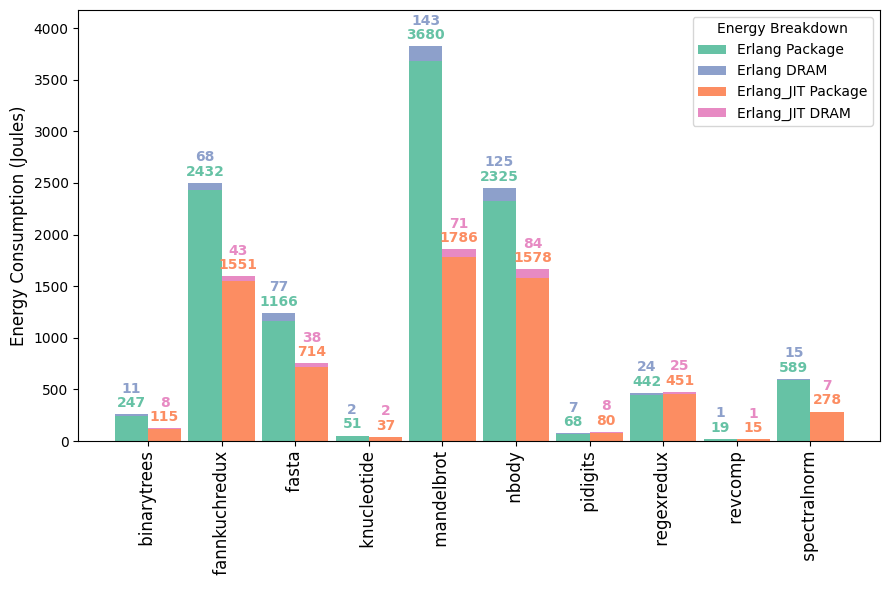

In [284]:
erlang_df = filtered_dfs[6].copy().round(0)
erlang_df["Program"] = erlang_df["Program"].str.split('.').str[0]

programs = erlang_df["Program"].unique()
languages = erlang_df["Language"].unique()

pivot_pkg = erlang_df.pivot(index="Program", columns="Language", values="Package")
pivot_dram = erlang_df.pivot(index="Program", columns="Language", values="DRAM")

x = np.arange(len(programs))
width = 0.45

# Colorblind-friendly palette
pkg_colors = ["#66c2a5", "#fc8d62"]
dram_colors = ["#8da0cb", "#e78ac3"]

fig, ax = plt.subplots(figsize=(9,6))

for i, lang in enumerate(languages):

    bar_offset = (i - 0.5) * width

    pkg = pivot_pkg[lang].values
    dram = pivot_dram[lang].values

    # Package bars
    pkg_bars = ax.bar(
        x + bar_offset,
        pkg,
        width,
        color=pkg_colors[i],
        label=f"{lang} Package"
    )

    # DRAM stacked bars
    dram_bars = ax.bar(
        x + bar_offset,
        dram,
        width,
        bottom=pkg,
        color=dram_colors[i],
        label=f"{lang} DRAM"
    )

    ymin, ymax = ax.get_ylim()
    offset = 0.01 * (ymax - ymin)

    for j in range(len(x)):

        total_height = pkg[j] + dram[j]

        # Package value (lower text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset,
            f"{pkg[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=pkg_colors[i],
            fontweight="bold"
        )

        # DRAM value (upper text)
        ax.text(
            x[j] + bar_offset,
            total_height + offset*4.5,
            f"{dram[j]:.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=dram_colors[i],
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(programs, rotation=90, fontsize=12)

ax.set_ylabel("Energy Consumption (Joules)", fontsize=12)

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.04)

legend_elements = [
    Patch(facecolor=pkg_colors[0], label=f"{languages[0]} Package"),
    Patch(facecolor=dram_colors[0], label=f"{languages[0]} DRAM"),
    Patch(facecolor=pkg_colors[1], label=f"{languages[1]} Package"),
    Patch(facecolor=dram_colors[1], label=f"{languages[1]} DRAM"),
]

ax.legend(handles=legend_elements, title="Energy Breakdown")

plt.tight_layout()
plt.savefig("Images/erlang_energy.pdf", bbox_inches='tight', format='pdf')
plt.show()

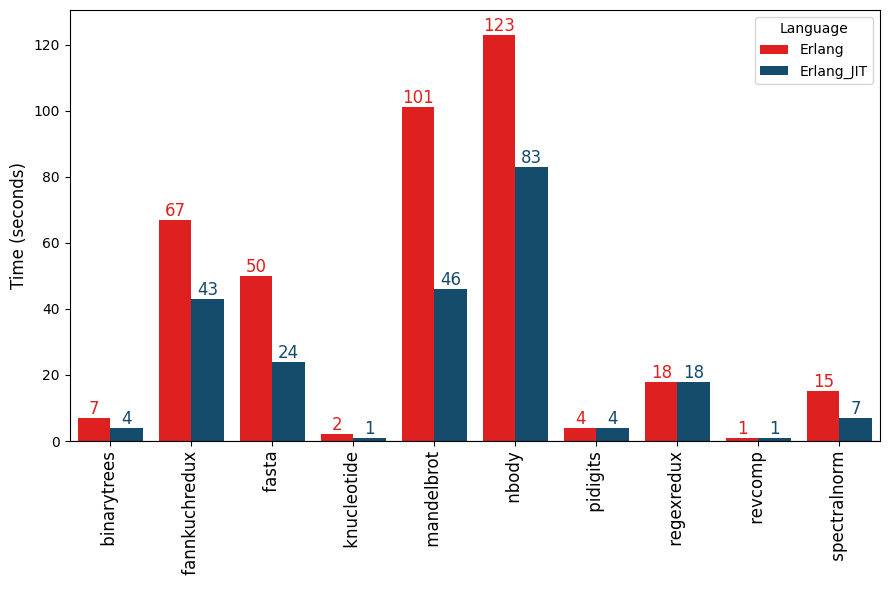

In [ ]:
plt.figure(figsize=(9,6))
colors = ["#FF0000", "#074F79"]

ax = sns.barplot(
    data=erlang_df,
    x="Program",
    y="Time",
    hue="Language",
    palette=colors
)

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Time (seconds)", fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.xlabel("")

for bar in ax.patches:
    height = bar.get_height()
    
    if height == 0: # skip fake zero bars
        continue

    x = bar.get_x() + bar.get_width() / 2

    ax.text(
        x,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        color=bar.get_facecolor(),
        fontsize=12
    )

# Headroom for labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.01)

plt.tight_layout()
plt.savefig("Images/erlang_time.pdf", bbox_inches='tight', format='pdf')
plt.show()


### Other graphs

In [226]:
combined_df = pd.concat(filtered_dfs, ignore_index=True)

df_base = combined_df[~combined_df["Language"].str.endswith("_JIT")].copy()
df_jit  = combined_df[combined_df["Language"].str.endswith("_JIT")].copy()

df_avg_base = df_base.groupby("Language")[["Package", "Time", "DRAM"]].mean().reset_index()
df_avg_jit  = df_jit.groupby("Language")[["Package", "Time", "DRAM"]].mean().reset_index()

df_avg_base = df_avg_base.sort_values(by=["Package", "Time", "DRAM"], ascending=True).reset_index(drop=True)
df_avg_jit  = df_avg_jit.sort_values(by=["Package", "Time", "DRAM"], ascending=True).reset_index(drop=True)

df_base = df_base[["Language", "Program", "Package", "Time", "DRAM"]].round(2).to_csv("df_base.csv", index=False)
df_jit = df_jit[["Language", "Program", "Package", "Time", "DRAM"]].round(2).to_csv("df_jit.csv", index=False)

print("Base languages average:")
print(df_avg_base)
print("\nJIT languages average:")
print(df_avg_jit)


Base languages average:
     Language      Package        Time        DRAM
0      Erlang  1101.877544   38.770832   47.375146
1         PHP  1140.678827   40.501970   47.143983
2        Java  1937.494587   75.888038   85.079778
3  Javascript  2421.703963   81.390511  130.855357
4      Python  2435.143609   79.400043   95.831017
5        Ruby  3705.873471  124.074257  144.139935
6         Lua  3915.555703  204.644508  218.523482

JIT languages average:
         Language      Package       Time       DRAM
0        Java_JIT   148.466653   5.301994   8.355753
1  Javascript_JIT   173.653175   5.836722   9.988949
2         Lua_JIT   388.061142  19.130216  23.851254
3      Erlang_JIT   660.367390  23.017551  28.599309
4      Python_JIT   682.881979  20.438380  68.706268
5         PHP_JIT   998.171933  35.169793  41.233693
6        Ruby_JIT  1997.614896  64.627737  80.791586


In [227]:
df_avg = combined_df.groupby("Language")[["Package", "Time", "DRAM"]].mean().reset_index()

df_avg = df_avg.sort_values(by=["Package", "Time", "DRAM"], ascending=True).reset_index(drop=True)

top_package = df_avg.loc[0, "Package"]
top_time    = df_avg.loc[0, "Time"]
top_dram    = df_avg.loc[0, "DRAM"]
top_packageDram = top_package + top_dram

df_ups = df_avg.copy()

df_ups["GreenUp"] = df_ups["Package"] / top_package
df_ups["SpeedUp"] = df_ups["Time"] / top_time
df_ups["PackageDRAMGreenUp"] = (df_ups["Package"]+df_ups["DRAM"]) / top_packageDram
df_ups["PowerUp"] = df_ups["SpeedUp"] / df_ups["PackageDRAMGreenUp"]

df_ups[["GreenUp (Package)", "GreenUp (Package+DRAM)", "SpeedUp", "PowerUp"]] = df_ups[["GreenUp", "PackageDRAMGreenUp", "SpeedUp", "PowerUp"]].round(2)
print(df_ups[["Language", "GreenUp (Package)", "GreenUp (Package+DRAM)", "SpeedUp", "PowerUp"]])

          Language  GreenUp (Package)  GreenUp (Package+DRAM)  SpeedUp  \
0         Java_JIT               1.00                    1.00     1.00   
1   Javascript_JIT               1.17                    1.17     1.10   
2          Lua_JIT               2.61                    2.63     3.61   
3       Erlang_JIT               4.45                    4.39     4.34   
4       Python_JIT               4.60                    4.79     3.85   
5          PHP_JIT               6.72                    6.63     6.63   
6           Erlang               7.42                    7.33     7.31   
7              PHP               7.68                    7.57     7.64   
8             Java              13.05                   12.90    14.31   
9         Ruby_JIT              13.45                   13.25    12.19   
10      Javascript              16.31                   16.28    15.35   
11          Python              16.40                   16.14    14.98   
12            Ruby              24.96 

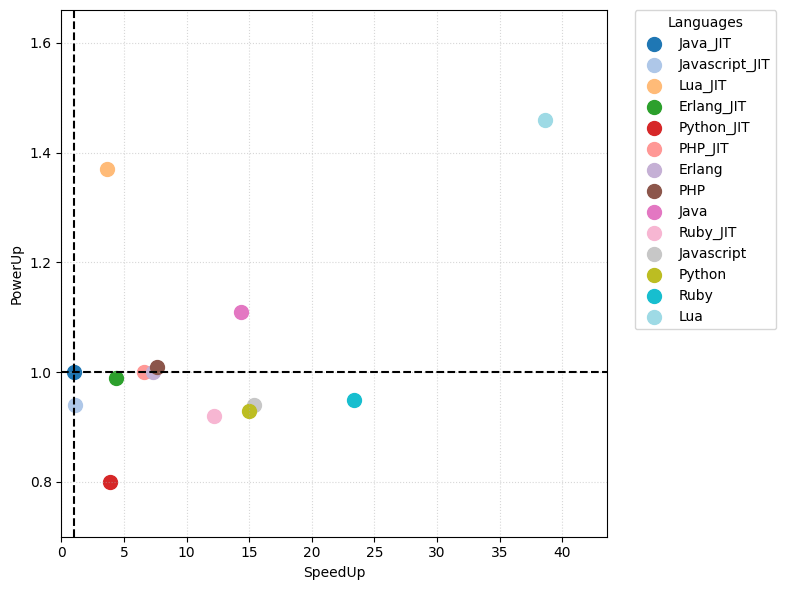

In [ ]:
df = pd.DataFrame(df_ups, columns=["Language", "SpeedUp", "PowerUp"])

# Create unique colors
cmap = colormaps["tab20"]
colors = cmap(np.linspace(0, 1, len(df)))

plt.figure(figsize=(8, 6))

# Plot each language separately (so legend works properly)
for i, row in df.iterrows():
    plt.scatter(row["SpeedUp"], row["PowerUp"], 
                color=colors[i], 
                s=100,
                label=row["Language"])

# Quadrant lines
plt.axvline(x=1.0, linestyle="--", color="black")
plt.axhline(y=1.0, linestyle="--", color="black")

# Labels and title
plt.xlabel("SpeedUp")
plt.ylabel("PowerUp")

plt.grid(True, linestyle=":", alpha=0.5)
plt.xlim(0, df["SpeedUp"].max() + 5)
plt.ylim(0.7, df["PowerUp"].max() + 0.2)


# Legend on the right side
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.,
    title="Languages"
)

plt.tight_layout()
plt.savefig("Images/gps_up.pdf", bbox_inches='tight', format='pdf')
plt.show()

In [229]:
top_package = df_avg_base.loc[0, "Package"]
top_time    = df_avg_base.loc[0, "Time"]
top_dram    = df_avg_base.loc[0, "DRAM"]

df_comparison = df_avg_base.copy()
df_comparison["Package"] = df_comparison["Package"] / top_package
df_comparison["Time"]    = df_comparison["Time"] / top_time
df_comparison["DRAM"]    = df_comparison["DRAM"] / top_dram
df_comparison["PowerUp"] = df_comparison["Time"]/df_comparison["Package"]

df_comparison[["Package", "Time", "DRAM", "PowerUp"]] = df_comparison[["Package", "Time", "DRAM", "PowerUp"]].round(2)

print(df_comparison)

     Language  Package  Time  DRAM  PowerUp
0      Erlang     1.00  1.00  1.00     1.00
1         PHP     1.04  1.04  1.00     1.01
2        Java     1.76  1.96  1.80     1.11
3  Javascript     2.20  2.10  2.76     0.96
4      Python     2.21  2.05  2.02     0.93
5        Ruby     3.36  3.20  3.04     0.95
6         Lua     3.55  5.28  4.61     1.49


In [230]:
top_package = df_avg_jit.loc[0, "Package"]
top_time    = df_avg_jit.loc[0, "Time"]
top_dram    = df_avg_jit.loc[0, "DRAM"]

df_comparison = df_avg_jit.copy()
df_comparison["Package"] = df_comparison["Package"] / top_package
df_comparison["Time"]    = df_comparison["Time"] / top_time
df_comparison["DRAM"]    = df_comparison["DRAM"] / top_dram
df_comparison["PowerUp"] = df_comparison["Time"]/df_comparison["Package"]

df_comparison[["Package", "Time", "DRAM", "PowerUp"]] = df_comparison[["Package", "Time", "DRAM", "PowerUp"]].round(2)

print(df_comparison)

         Language  Package   Time  DRAM  PowerUp
0        Java_JIT     1.00   1.00  1.00     1.00
1  Javascript_JIT     1.17   1.10  1.20     0.94
2         Lua_JIT     2.61   3.61  2.85     1.38
3      Erlang_JIT     4.45   4.34  3.42     0.98
4      Python_JIT     4.60   3.85  8.22     0.84
5         PHP_JIT     6.72   6.63  4.93     0.99
6        Ruby_JIT    13.45  12.19  9.67     0.91


In [231]:
df_base = df_avg_base.copy()
df_jit = df_avg_jit.copy()

# Remove "_JIT" suffix so language names match
df_jit["Language"] = df_jit["Language"].str.replace("_JIT", "", regex=False)

# Merge on Language
df_merged = df_base.merge(df_jit, on="Language", suffixes=("_base", "_jit"))

df_merged["Energy_Gain"] = (
    (df_merged["Package_base"] - df_merged["Package_jit"]) 
    / df_merged["Package_base"] * -100
)

df_merged["Time_Gain"] = (
    (df_merged["Time_base"] - df_merged["Time_jit"]) 
    / df_merged["Time_base"] * -100
)

df_merged["DRAM_Gain"] = (
    (df_merged["DRAM_base"] - df_merged["DRAM_jit"]) 
    / df_merged["DRAM_base"] * -100
)

df_gain = df_merged[["Language","Energy_Gain","Time_Gain","DRAM_Gain"]]

df_gain = df_gain.round(2).sort_values(by=["Energy_Gain", "Time_Gain"], ascending=False)
df_gain_energy = df_gain.round(2).sort_values(by=["Energy_Gain"], ascending=False)
df_gain_time = df_gain.round(2).sort_values(by=["Time_Gain"], ascending=False)
df_gain_dram = df_gain.round(2).sort_values(by=["DRAM_Gain"], ascending=False)

print(df_gain)

     Language  Energy_Gain  Time_Gain  DRAM_Gain
1         PHP       -12.49     -13.17     -12.54
0      Erlang       -40.07     -40.63     -39.63
5        Ruby       -46.10     -47.91     -43.95
4      Python       -71.96     -74.26     -28.30
6         Lua       -90.09     -90.65     -89.09
2        Java       -92.34     -93.01     -90.18
3  Javascript       -92.83     -92.83     -92.37


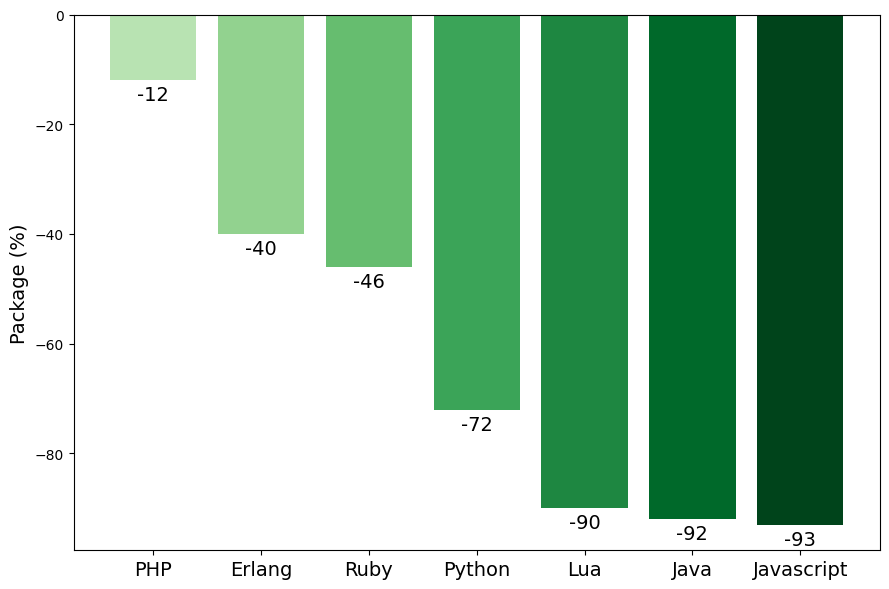

In [245]:
df_plot = df_gain_energy.set_index("Language").round(0)

x = np.arange(len(df_plot.index))
width = 0.8

plt.figure(figsize=(9, 6))

colormap = colormaps["Greens"]
colors = [colormap(i) for i in np.linspace(0.3, 1, len(df_plot.index))]  # Start from 0.3 to avoid too-light colors

bars = plt.bar(x, df_plot["Energy_Gain"], width, color=colors)

# Add value labels just above the bars (for negative values)
for bar in bars:
    height = bar.get_height()
    y_pos = height - 0.01 * max(abs(df_plot["Energy_Gain"]))
    plt.text(bar.get_x() + bar.get_width() / 2,
             y_pos,
             f"{height:.0f}",
             ha="center", va="top", color="black",
             fontsize=14)

plt.xticks(x, df_plot.index, fontsize=14)
plt.ylabel("Package (%)", fontsize=14)

plt.tight_layout()
plt.savefig("Images/energy_gain.pdf", bbox_inches='tight', format='pdf')
plt.show()

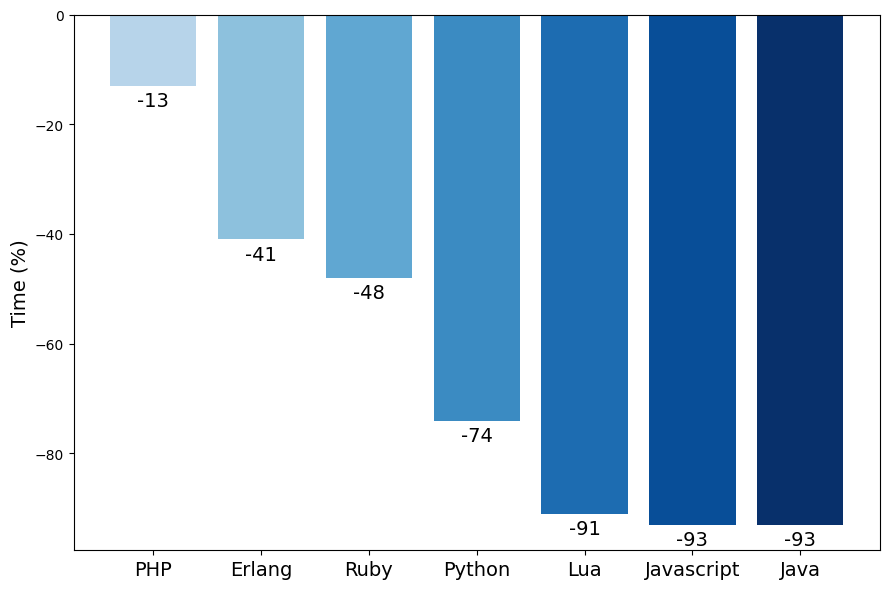

In [244]:
df_plot = df_gain_time.set_index("Language").round(0)

x = np.arange(len(df_plot.index))
width = 0.8

plt.figure(figsize=(9, 6))

colormap = colormaps["Blues"]
colors = [colormap(i) for i in np.linspace(0.3, 1, len(df_plot.index))]  # Start from 0.3 to avoid too-light colors

bars = plt.bar(x, df_plot["Time_Gain"], width, color=colors)

# Add value labels just above the bars (for negative values)
for bar in bars:
    height = bar.get_height()
    y_pos = height - 0.01 * max(abs(df_plot["Time_Gain"]))
    plt.text(bar.get_x() + bar.get_width() / 2,
             y_pos,
             f"{height:.0f}",
             ha="center", va="top", color="black",
             fontsize=14)

plt.xticks(x, df_plot.index, fontsize=14)
plt.ylabel("Time (%)", fontsize=14)

plt.tight_layout()
plt.savefig("Images/time_gain.pdf", bbox_inches='tight', format='pdf')
plt.show()


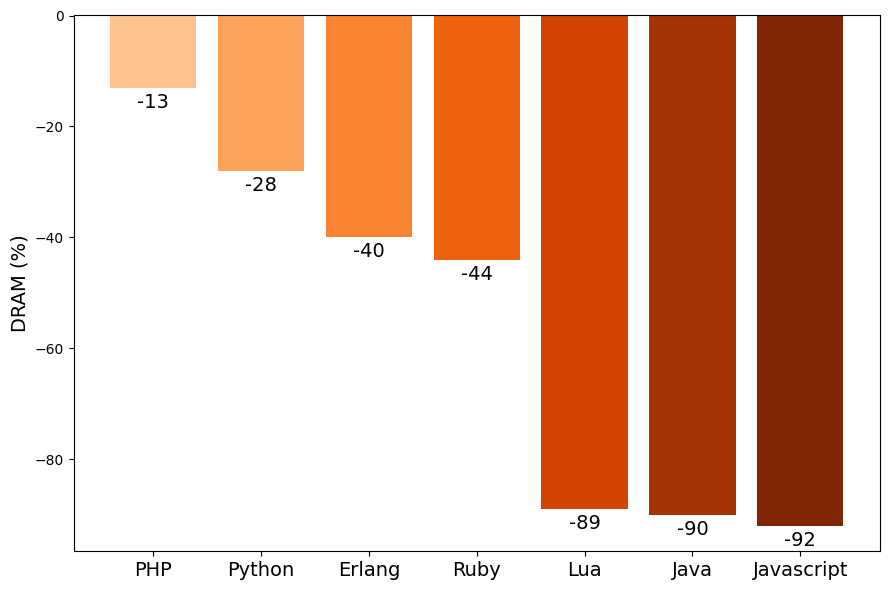

In [243]:
df_plot = df_gain_dram.set_index("Language").round(0)

x = np.arange(len(df_plot.index))
width = 0.8

plt.figure(figsize=(9, 6))

colormap = colormaps["Oranges"]
colors = [colormap(i) for i in np.linspace(0.3, 1, len(df_plot.index))]  # Start from 0.3 to avoid too-light colors

bars = plt.bar(x, df_plot["DRAM_Gain"], width, color=colors)

# Add value labels just above the bars (for negative values)
for bar in bars:
    height = bar.get_height()
    y_pos = height - 0.01 * max(abs(df_plot["DRAM_Gain"]))
    plt.text(bar.get_x() + bar.get_width() / 2,
             y_pos,
             f"{height:.0f}",
             ha="center", va="top", color="black",
             fontsize=14)

plt.xticks(x, df_plot.index, fontsize=14)
plt.ylabel("DRAM (%)", fontsize=14)

plt.tight_layout()
plt.savefig("Images/dram_gain.pdf", bbox_inches='tight', format='pdf')
plt.show()
